# Análisis exploratorio del precio de la luz (PVPC)

**Objetivo:** entender cómo se comporta el PVPC antes de modelarlo. Qué tendencia tiene, qué patrones se repiten (por mes, por día de la semana y por hora) y qué ha cambiado en los últimos años. Cada sección termina con lo que implica para el modelo.

**Datos:** PVPC horario de la API pública de Red Eléctrica (REE), desde junio de 2021. Los precios están en €/MWh (1 €/MWh = 0,001 €/kWh) y las horas, en hora local de Madrid.

> Para reproducirlo: `make backfill` descarga los datos y después se ejecuta este notebook.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.ingestion.prices import load_pvpc
from src.processing.clean import clean_prices
from src.processing.features import build_features

INK, BLUE, AMBER, GREY = "#0E1726", "#1F4E9C", "#E99A1E", "#A9B4C2"
YEAR_COLORS = {2022: "#C9D2DE", 2023: "#A9C4EB", 2024: "#6F9BE0", 2025: "#1F4E9C", 2026: AMBER}
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.float_format", "{:.1f}".format)

prices = clean_prices(load_pvpc())
local = prices.tz_convert("Europe/Madrid")
price = local["price"]
year, month, hour, weekday = local.index.year, local.index.month, local.index.hour, local.index.dayofweek

## 1. Visión general

In [2]:
n_hours = f"{len(prices):,}".replace(",", ".")
print(f"{n_hours} horas, del {local.index.min():%d/%m/%Y} al {local.index.max():%d/%m/%Y}")
print(f"Horas sin precio: {prices['price'].isna().sum()} · interpoladas: {prices['is_interpolated'].sum()}")
price.groupby(year).agg(media="mean", mediana="median", desviación="std", mínimo="min", máximo="max", horas="count")

46.872 horas, del 01/06/2021 al 05/10/2026
Horas sin precio: 0 · interpoladas: 0


,media,mediana,desviación,mínimo,máximo,horas
datetime,,,,,,
2021,217.7,222.7,86.0,18.6,536.8,5137
2022,287.3,284.0,106.1,11.7,954.0,8760
2023,146.8,147.8,57.3,16.8,357.2,8760
2024,127.8,126.5,54.7,19.5,318.4,8784
2025,136.4,133.9,56.1,20.6,423.1,8760
2026,143.3,135.6,71.3,-12.6,431.3,6671


2021 empieza en junio y 2026 llega hasta octubre, así que esos dos años son parciales. La serie no tiene ningún hueco: REE publica todas las horas.

## 2. Tendencia

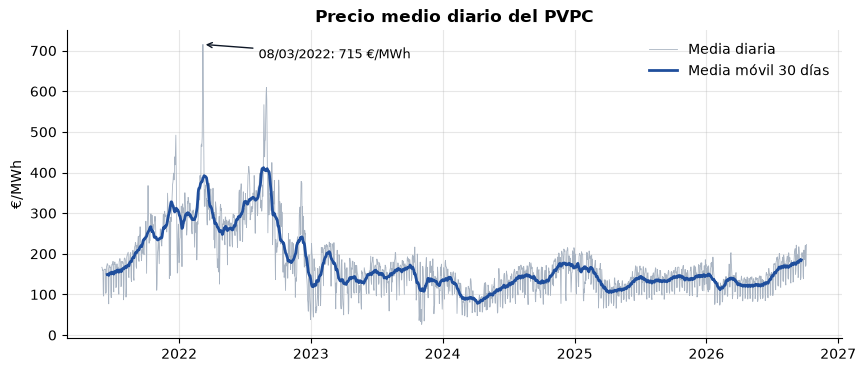

In [3]:
daily = price.resample("D").mean()
fig, ax = plt.subplots()
ax.plot(daily.index, daily, color=GREY, lw=0.6, label="Media diaria")
ax.plot(daily.index, daily.rolling(30, center=True).mean(), color=BLUE, lw=2, label="Media móvil 30 días")
peak = daily.idxmax()
ax.annotate(f"{peak:%d/%m/%Y}: {daily.max():.0f} €/MWh", xy=(peak, daily.max()), xytext=(40, -10),
            textcoords="offset points", arrowprops={"arrowstyle": "->", "color": INK}, fontsize=9)
ax.set(title="Precio medio diario del PVPC", ylabel="€/MWh")
ax.legend(frameon=False)
plt.show()

**Dos épocas muy distintas:**

- **2021–2022, crisis del gas:** media de 287 €/MWh en 2022, con el día más caro el 8 de marzo de 2022 (715 €/MWh de media) y la hora más cara, 954 €/MWh, ese mismo día a las 19:00.
- **Desde 2023, estabilidad:** medias anuales entre 128 y 147 €/MWh. En 2026 sube a final de verano: 184 €/MWh en septiembre y 199 en los primeros días de octubre.

→ **Para el modelo:** entrenar con todo el histórico mezcla dos regímenes. El modelo debe apoyarse en los precios recientes (retardos) más que en el nivel absoluto, y la validación debe hacerse sobre el periodo reciente.

## 3. Estacionalidad mensual

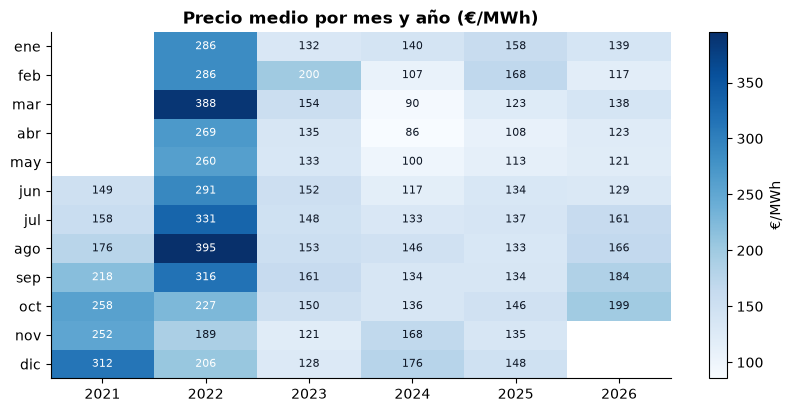

In [4]:
monthly = price.groupby([year, month]).mean().unstack(0)
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(monthly.to_numpy(), aspect="auto", cmap="Blues")
ax.set_xticks(range(len(monthly.columns)), monthly.columns)
ax.set_yticks(range(12), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
for (i, j), v in pd.DataFrame(monthly.to_numpy()).stack().items():
    if pd.notna(v):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 200 else INK)
ax.set(title="Precio medio por mes y año (€/MWh)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="€/MWh")
plt.show()

No hay un patrón mensual que se repita igual cada año. En 2022 el mes más caro fue agosto (395 €/MWh); en 2024, marzo y abril fueron los más baratos (90 y 86 €/MWh). La primavera tiende a ser barata, pero con mucha variación entre años.

→ **Para el modelo:** el mes explica poco por sí solo. `month` y `dayofyear` son variables de apoyo, no las principales.

## 4. Día de la semana

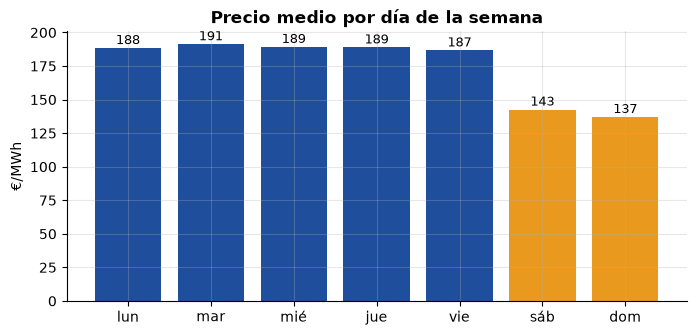

Fin de semana: 139.8 €/MWh · laborables: 188.8 €/MWh · diferencia: -26 %


In [5]:
names = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
by_weekday = price.groupby(weekday).mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(names, by_weekday, color=[BLUE] * 5 + [AMBER] * 2)
for i, v in enumerate(by_weekday):
    ax.text(i, v + 3, f"{v:.0f}", ha="center", fontsize=9)
ax.set(title="Precio medio por día de la semana", ylabel="€/MWh")
plt.show()

weekend, working = price[weekday >= 5].mean(), price[weekday < 5].mean()
print(f"Fin de semana: {weekend:.1f} €/MWh · laborables: {working:.1f} €/MWh · diferencia: {(weekend / working - 1) * 100:.0f} %")

Los cinco laborables son prácticamente iguales (187–191 €/MWh). El fin de semana es un **26 % más barato**, y el domingo, el día más barato.

→ **Para el modelo:** `is_weekend` y `dayofweek` son imprescindibles. Además, el lunes no se parece al domingo anterior, así que el retardo de 7 días (`price_lag_7d`) aporta algo que el de 1 día no tiene.

## 5. Perfil horario y su evolución

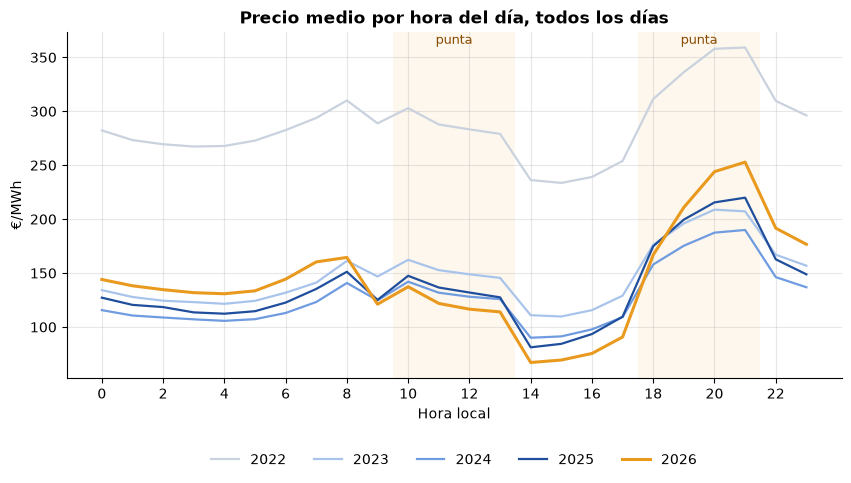

,hora más barata,precio mínimo,hora más cara,precio máximo,máximo / mínimo
datetime,,,,,
2022,15,233.6,21,359.2,1.5
2023,15,109.7,20,208.8,1.9
2024,14,90.1,21,190.0,2.1
2025,14,81.2,21,219.9,2.7
2026,14,67.1,21,252.9,3.8


In [6]:
profile = price[year >= 2022].groupby([year[year >= 2022], hour[year >= 2022]]).mean().unstack(0)
fig, ax = plt.subplots(figsize=(10, 4.5))
for start, end in [(10, 14), (18, 22)]:
    ax.axvspan(start - 0.5, end - 0.5, color=AMBER, alpha=0.08, lw=0)
for y, color in YEAR_COLORS.items():
    ax.plot(profile.index, profile[y], color=color, lw=2.2 if y == 2026 else 1.6, label=str(y))
ax.text(11.5, ax.get_ylim()[1] * 0.97, "punta", ha="center", fontsize=9, color="#8A4B00")
ax.text(19.5, ax.get_ylim()[1] * 0.97, "punta", ha="center", fontsize=9, color="#8A4B00")
ax.set(title="Precio medio por hora del día, todos los días", xlabel="Hora local", ylabel="€/MWh", xticks=range(0, 24, 2))
ax.legend(frameon=False, ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.show()

summary = pd.DataFrame({
    "hora más barata": profile.idxmin(), "precio mínimo": profile.min(),
    "hora más cara": profile.idxmax(), "precio máximo": profile.max(), "máximo / mínimo": profile.max() / profile.min(),
})
summary

Es el gráfico más revelador:

1. **El mediodía es cada vez más barato:** la hora más barata pasa de 234 €/MWh (15:00, 2022) a 67 €/MWh (14:00, 2026). Coincide con el crecimiento de la solar.
2. **El pico de la noche (20–21 h) se mantiene o sube.** La hora más cara multiplica a la más barata por 1,5 en 2022 y por **3,8 en 2026**.
3. **Saltos bruscos a las 10:00, 14:00 y 18:00:** son los cambios de tramo de la tarifa 2.0TD (llano ↔ punta). El PVPC incluye peajes y cargos distintos en cada tramo, así que el precio salta aunque el mercado no lo haga.

→ **Para el modelo:** `hour` y `tariff_period` son imprescindibles. Como la forma del día cambia de un año a otro, conviene dar más peso a lo reciente.

## 6. Volatilidad dentro del día

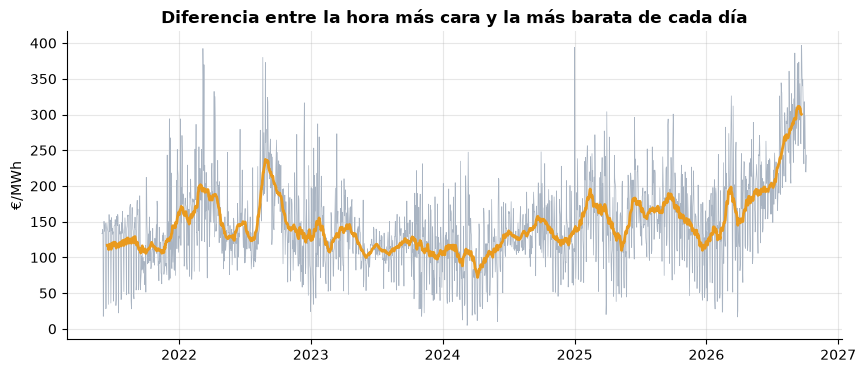

datetime,2021,2022,2023,2024,2025,2026
rango medio diario (€/MWh),119.8,161.8,119.7,120.0,157.6,201.7


In [7]:
daily_range = price.resample("D").max() - price.resample("D").min()
fig, ax = plt.subplots()
ax.plot(daily_range.index, daily_range, color=GREY, lw=0.5)
ax.plot(daily_range.index, daily_range.rolling(30, center=True).mean(), color=AMBER, lw=2)
ax.set(title="Diferencia entre la hora más cara y la más barata de cada día", ylabel="€/MWh")
plt.show()
daily_range.groupby(daily_range.index.year).mean().rename("rango medio diario (€/MWh)").to_frame().T

La volatilidad dentro del día crece: la diferencia media entre la hora más cara y la más barata pasa de 120 €/MWh en 2023–2024 a 158 en 2025 y **202 en 2026**, con días de más de 300 €/MWh en el verano de 2026.

→ **Para el modelo:** acertar la forma del día (cuándo es barato y cuándo caro) importa cada vez más que acertar el nivel medio. Es justo lo que necesitan el simulador y el planificador.

## 7. Precios negativos y muy bajos

In [8]:
low = pd.DataFrame({
    "horas < 0 €/MWh": (price < 0).groupby(year).sum(),
    "horas < 20 €/MWh": (price < 20).groupby(year).sum(),
})
display(low.T)
negative = price[price < 0]
print(f"Las {len(negative)} horas negativas caen entre las {negative.index.hour.min()}:00 y las {negative.index.hour.max()}:00;"
      f" la más baja: {negative.min():.2f} €/MWh el {negative.idxmin():%d/%m/%Y a las %H:%M}")

datetime,2021,2022,2023,2024,2025,2026
horas < 0 €/MWh,0,0,0,0,0,18
horas < 20 €/MWh,3,4,3,1,0,152


Las 18 horas negativas caen entre las 11:00 y las 16:00; la más baja: -12.63 €/MWh el 26/09/2026 a las 14:00


Hasta 2025 casi no había horas por debajo de 20 €/MWh (entre 0 y 4 al año). En 2026 hay **152**, y por primera vez **18 horas con precio negativo**, todas a mediodía, entre las 11:00 y las 16:00.

→ **Para el modelo:** no se debe recortar la previsión a 0. Un precio negativo es un resultado real y cada vez más frecuente.

## 8. ¿Qué información sirve para predecir?

In [9]:
features = build_features(prices)
cols = ["price_lag_1d", "same_hour_mean_7d", "price_lag_7d", "prev_day_mean", "prev_7d_mean"]
features[["price", *cols]].corr()["price"].drop("price").map("{:.3f}".format).rename("correlación con el precio").to_frame()

,correlación con el precio
price_lag_1d,0.864
same_hour_mean_7d,0.856
price_lag_7d,0.828
prev_day_mean,0.783
prev_7d_mean,0.756


In [10]:
errors = pd.DataFrame({
    "precio de ayer": (features["price"] - features["price_lag_1d"]).abs(),
    "media 7 días": (features["price"] - features["same_hour_mean_7d"]).abs(),
}).groupby(features.index.tz_convert("Europe/Madrid").year).mean()
errors.T.rename_axis("error medio por hora (€/MWh)")

datetime,2021,2022,2023,2024,2025,2026
error medio por hora (€/MWh),,,,,,
precio de ayer,31.0,45.9,31.0,26.5,27.9,29.4
media 7 días,37.7,52.1,35.1,28.4,28.6,29.1


El precio de la misma hora de ayer es la variable más correlacionada con el precio (0,864), seguida de la media de esa hora en los últimos 7 días (0,856).

Usadas directamente como previsión, **"precio de ayer" falla menos que "media 7 días" en todos los años salvo 2026**, donde prácticamente empatan (29,4 frente a 29,1 €/MWh). En el prototipo, con solo 30 días de datos, salía lo contrario: un periodo corto puede engañar.

→ **Para el modelo:** la referencia que LightGBM tiene que batir se decidirá con el backtest de la Fase 3 sobre todo el histórico, no con una ventana corta.

## Conclusiones

| Hallazgo | Implicación para el modelo |
|---|---|
| Dos regímenes: crisis del gas (2021–2022) y estabilidad desde 2023 | Apoyarse en precios recientes y validar en el periodo reciente |
| Fin de semana un 26 % más barato | `is_weekend`, `dayofweek` y el retardo de 7 días |
| Mediodía cada vez más barato y noche más cara (de 1,5 a 3,8 veces) | `hour` es clave y la forma del día cambia con los años |
| Saltos a las 10, 14 y 18 h por los peajes de cada tramo | `tariff_period` como variable explícita |
| Volatilidad dentro del día en aumento (202 €/MWh de media en 2026) | Lo importante es acertar la forma del día, no solo el nivel |
| Primeros precios negativos en 2026 | No recortar la previsión a 0 |
| "Precio de ayer" es la mejor referencia simple en casi todos los años | El backtest de la Fase 3 decidirá la referencia a batir |

Siguiente paso: el notebook `02_mix_generacion.ipynb`, que estudia cómo influye cada tecnología de generación en el precio.